# Evaluacion y exportacion de los modelos finales

In [ ]:
import pandas as pd
dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')
dt_quejas.head(20)

<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\Jon\AppData\Local\Temp\ipykernel_20432\1902781302.py:3: SyntaxWarning: invalid escape sequence '\d'
  dt_quejas = pd.read_csv('..\data\dt_quejas_corr.csv')


,Complaint ID,Product,Sub-product,Issue,State,ZIP code,Date received,Date sent to company,Company,Company response,Timely response?,Consumer disputed?,Company_grouped_filtered,Difference in days
0,1291006,Debt collection,Credit card,Communication tactics,TX,76119,2015-03-19,2015-03-19,"Premium Asset Services, LLC",In progress,Yes,Pending,Low Count Companies,0
1,1290580,Debt collection,Medical,Cont'd attempts collect debt not owed,TX,77479,2015-03-19,2015-03-19,Accounts Receivable Consultants Inc.,Closed with explanation,Yes,No,Low Count Companies,0
2,1290564,Mortgage,FHA mortgage,"Application, originator, mortgage broker",MA,02127,2015-03-19,2015-03-19,RBS Citizens,Closed with explanation,Yes,Yes,RBS Citizens,0
3,1291615,Credit card,Unknown,Other,CA,92592,2015-03-19,2015-03-19,Navy FCU,In progress,Yes,Pending,Navy FCU,0
4,1292165,Debt collection,Non-federal student loan,Cont'd attempts collect debt not owed,OH,43068,2015-03-19,2015-03-19,Transworld Systems Inc.,In progress,Yes,Pending,Transworld Systems Inc.,0
5,1291176,Debt collection,Payday loan,Communication tactics,OH,43068,2015-03-19,2015-03-19,ACE Cash Express Inc.,In progress,Yes,Pending,ACE Cash Express Inc.,0
6,1288848,Consumer loan,Installment loan,Managing the loan or lease,OH,44241,2015-03-18,2015-03-18,"CashCall, Inc.",Closed with explanation,Yes,Yes,"CashCall, Inc.",0
7,1288788,Debt collection,Payday loan,Communication tactics,CA,95124,2015-03-18,2015-03-18,ACE Cash Express Inc.,Closed with explanation,Yes,No,ACE Cash Express Inc.,0
8,1288324,Debt collection,"Other (phone, health club, etc.)",Cont'd attempts collect debt not owed,NJ,07067,2015-03-18,2015-03-18,"Credit Protection Association, L.P.",Closed with non-monetary relief,Yes,No,Low Count Companies,0
9,1288304,Debt collection,Payday loan,Taking/threatening an illegal action,TX,77433,2015-03-18,2015-03-18,Cottonwood Financial Ltd.,Closed with explanation,Yes,Yes,Low Count Companies,0


In [2]:
import sys, os , joblib
sys.path.append(os.path.abspath(os.path.join("..", "src")))

import preprocessing_01
import training_01
import evaluation_01


Classification report:
               precision    recall  f1-score   support

           0       0.84      0.61      0.70      4082
           1       1.00      1.00      1.00       608
           2       0.23      0.50      0.31       942

    accuracy                           0.63      5632
   macro avg       0.69      0.70      0.67      5632
weighted avg       0.76      0.63      0.67      5632


Matriz de confusión:
 [[2476    0 1606]
 [   0  608    0]
 [ 469    0  473]]

Métricas adicionales:
Accuracy: 0.6316
F1-score (macro): 0.6726
AUC OvR (macro): 0.7990


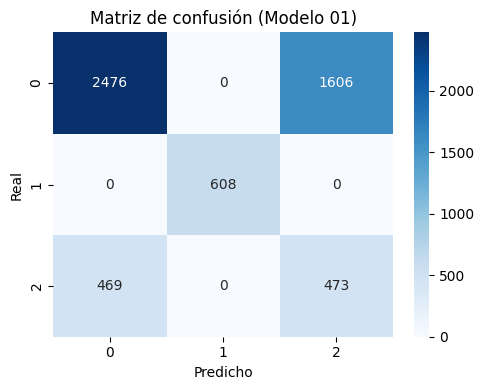

In [ ]:
X, y_num, label_to_num, labels = preprocessing_01.prepare_data(dt_quejas)
resultados_01 = training_01.entrenar_xgb_pesos_resultados(X, y_num, labels=labels)
metrics_01 = evaluation_01.evaluar_modelo_resultados(resultados_01)

In [ ]:
joblib.dump(resultados_01["model"], "../models/final_model_01.pkl")

['../models/final_model_01.pkl']

In [6]:
import preprocessing_02
import training_02
import evaluation_02

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Matriz de confusión:
 [[  95   47]
 [ 539 4951]]

Reporte de clasificación:
               precision    recall  f1-score   support

          No       0.15      0.67      0.24       142
         Yes       0.99      0.90      0.94      5490

    accuracy                           0.90      5632
   macro avg       0.57      0.79      0.59      5632
weighted avg       0.97      0.90      0.93      5632


Métricas adicionales:
Accuracy: 0.8960
Precision (macro): 0.5702
Recall (macro): 0.7854
F1-score (macro): 0.5945
F1-score (weighted): 0.9265
ROC AUC (binario): 0.9059

 Mejores parámetros: {'clf__colsample_bytree': 1.0, 'clf__learning_rate': 0.1, 'clf__max_depth': 6, 'clf__n_estimators': 500, 'clf__subsample': 0.8}
 Mejor F1-macro (CV): 0.6083


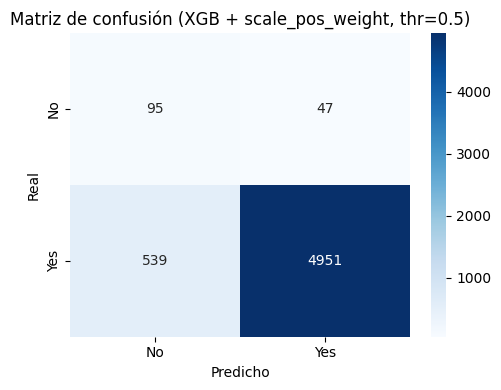

In [7]:
X, y_num, map_y = preprocessing_02.prepare_data_timely(dt_quejas)
labels = ['No', 'Yes']
resultados_02 = training_02.entrenar_xgb_weight_timely(X, y_num, threshold=0.5)
metrics_02 = evaluation_02.evaluar_xgb_weight_timely(resultados_02)


In [ ]:
joblib.dump(resultados_02["best_model"], "../models/final_model_02.pkl")

['../models/final_model_02.pkl']

In [9]:
import preprocessing_03
import training_03
import evaluation_03

In [10]:
X, y = preprocessing_03.prepare_data_delay(dt_quejas)
resultados_03 = training_03.entrenar_xgb_delay(X, y)
metrics_03 = evaluation_03.evaluar_xgb_delay(resultados_03)

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Mejores parámetros: {'clf__subsample': 0.8, 'clf__n_estimators': 500, 'clf__max_depth': 10, 'clf__learning_rate': 0.1, 'clf__colsample_bytree': 1.0}

Classification report:
               precision    recall  f1-score   support

           0       0.76      0.85      0.80      3926
           1       0.52      0.28      0.36      1501
           2       0.22      0.42      0.29       205

    accuracy                           0.68      5632
   macro avg       0.50      0.52      0.49      5632
weighted avg       0.67      0.68      0.67      5632


Matriz de confusión:
 [[3346  367  213]
 [ 994  422   85]
 [  89   30   86]]
Quadratic Weighted Kappa: 0.2542428069300223
ROC AUC (multiclase, OVR-macro): 0.7162


In [ ]:
joblib.dump(resultados_03["best_model"], "../models/final_model_03.pkl")

['../models/final_model_03.pkl']